# Financial Data Cleaning and Analysis Project

## Objective

This project demonstrates basic financial data cleaning, transformation and analysis using Python and Pandas.

The raw dataset contains deliberately introduced data-quality issues, including missing values, duplicate records and inconsistent text formatting.

The objective is to:

- inspect the raw dataset
- identify data-quality problems
- clean and standardise the data
- create calculated financial metrics
- perform basic financial analysis
- export a cleaned dataset for further SQL and reporting work

This project was completed as a practical skills exercise for my professional portfolio.

In [1]:
import pandas as pd

df = pd.read_csv("financial_data_raw.csv")

df.head()

,Date,Company,Sector,Revenue,Cost,Region
0,2026-01-05,Apple,Technology,120000.0,80000.0,USA
1,2026-01-12,Microsoft,Technology,110000.0,72000.0,USA
2,2026-01-19,Tesla,Automotive,90000.0,70000.0,USA
3,2026-01-26,Barclays,Banking,85000.0,50000.0,UK
4,2026-02-02,HSBC,Banking,95000.0,55000.0,UK


In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 26 entries, 0 to 25
Data columns (total 6 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Date     26 non-null     str    
 1   Company  26 non-null     str    
 2   Sector   26 non-null     str    
 3   Revenue  25 non-null     float64
 4   Cost     25 non-null     float64
 5   Region   26 non-null     str    
dtypes: float64(2), str(4)
memory usage: 1.3 KB


In [3]:
df.isnull().sum()

Date       0
Company    0
Sector     0
Revenue    1
Cost       1
Region     0
dtype: int64

In [4]:
df.duplicated().sum()

np.int64(1)

In [5]:
df[df.duplicated()]

,Date,Company,Sector,Revenue,Cost,Region
25,2026-06-22,HSBC,Banking,112000.0,64000.0,UK


In [6]:
df["Company"].unique()

<StringArray>
['Apple', 'Microsoft', 'Tesla', 'Barclays', 'HSBC', 'apple']
Length: 6, dtype: str

In [7]:
df["Region"].unique()

<StringArray>
['USA', 'UK', 'usa']
Length: 3, dtype: str

In [8]:
df = df.drop_duplicates()

print("Number of duplicate rows:", df.duplicated().sum())
print("Number of rows remaining:", len(df))

Number of duplicate rows: 0
Number of rows remaining: 25


In [9]:
df["Company"] = df["Company"].str.strip().str.title()

df["Company"].unique()

<StringArray>
['Apple', 'Microsoft', 'Tesla', 'Barclays', 'Hsbc']
Length: 5, dtype: str

In [10]:
df["Region"] = df["Region"].str.strip().str.upper()

df["Region"].unique()

<StringArray>
['USA', 'UK']
Length: 2, dtype: str

In [11]:
df["Revenue"] = df["Revenue"].fillna(
    df.groupby("Company")["Revenue"].transform("median")
)

df["Cost"] = df["Cost"].fillna(
    df.groupby("Company")["Cost"].transform("median")
)

In [12]:
df.isnull().sum()

Date       0
Company    0
Sector     0
Revenue    0
Cost       0
Region     0
dtype: int64

In [13]:
df.dtypes

Date           str
Company        str
Sector         str
Revenue    float64
Cost       float64
Region         str
dtype: object

In [14]:
df["Date"] = pd.to_datetime(df["Date"])

df.dtypes

Date       datetime64[us]
Company               str
Sector                str
Revenue           float64
Cost              float64
Region                str
dtype: object

In [15]:
df["Profit"] = df["Revenue"] - df["Cost"]

df["Profit_Margin_%"] = (df["Profit"] / df["Revenue"]) * 100

df.head()

,Date,Company,Sector,Revenue,Cost,Region,Profit,Profit_Margin_%
0,2026-01-05,Apple,Technology,120000.0,80000.0,USA,40000.0,33.333333
1,2026-01-12,Microsoft,Technology,110000.0,72000.0,USA,38000.0,34.545455
2,2026-01-19,Tesla,Automotive,90000.0,70000.0,USA,20000.0,22.222222
3,2026-01-26,Barclays,Banking,85000.0,50000.0,UK,35000.0,41.176471
4,2026-02-02,Hsbc,Banking,95000.0,55000.0,UK,40000.0,42.105263


In [16]:
df["Profit_Margin_%"] = df["Profit_Margin_%"].round(2)

df.head()

,Date,Company,Sector,Revenue,Cost,Region,Profit,Profit_Margin_%
0,2026-01-05,Apple,Technology,120000.0,80000.0,USA,40000.0,33.33
1,2026-01-12,Microsoft,Technology,110000.0,72000.0,USA,38000.0,34.55
2,2026-01-19,Tesla,Automotive,90000.0,70000.0,USA,20000.0,22.22
3,2026-01-26,Barclays,Banking,85000.0,50000.0,UK,35000.0,41.18
4,2026-02-02,Hsbc,Banking,95000.0,55000.0,UK,40000.0,42.11


In [17]:
company_summary = df.groupby("Company").agg(
    Total_Revenue=("Revenue", "sum"),
    Total_Cost=("Cost", "sum"),
    Total_Profit=("Profit", "sum"),
    Average_Profit_Margin=("Profit_Margin_%", "mean")
).round(2)

company_summary

,Total_Revenue,Total_Cost,Total_Profit,Average_Profit_Margin
Company,,,,
Apple,685000.0,442000.0,243000.0,35.38
Barclays,471000.0,270000.0,201000.0,42.65
Hsbc,517000.0,298000.0,219000.0,42.33
Microsoft,650000.0,402000.0,248000.0,38.00
Tesla,499000.0,360000.0,139000.0,27.73


In [18]:
company_summary.sort_values("Total_Profit", ascending=False)

,Total_Revenue,Total_Cost,Total_Profit,Average_Profit_Margin
Company,,,,
Microsoft,650000.0,402000.0,248000.0,38.00
Apple,685000.0,442000.0,243000.0,35.38
Hsbc,517000.0,298000.0,219000.0,42.33
Barclays,471000.0,270000.0,201000.0,42.65
Tesla,499000.0,360000.0,139000.0,27.73


In [19]:
sector_summary = df.groupby("Sector").agg(
    Total_Revenue=("Revenue", "sum"),
    Total_Cost=("Cost", "sum"),
    Total_Profit=("Profit", "sum")
).round(2)

sector_summary

,Total_Revenue,Total_Cost,Total_Profit
Sector,,,
Automotive,499000.0,360000.0,139000.0
Banking,988000.0,568000.0,420000.0
Technology,1335000.0,844000.0,491000.0


In [20]:
df["Month"] = df["Date"].dt.to_period("M")

monthly_summary = df.groupby("Month").agg(
    Total_Revenue=("Revenue", "sum"),
    Total_Cost=("Cost", "sum"),
    Total_Profit=("Profit", "sum")
)

monthly_summary

,Total_Revenue,Total_Cost,Total_Profit
Month,,,
2026-01,405000.0,272000.0,133000.0
2026-02,451000.0,286000.0,165000.0
2026-03,564000.0,353000.0,211000.0
2026-04,483000.0,290000.0,193000.0
2026-05,458000.0,287000.0,171000.0
2026-06,461000.0,284000.0,177000.0


Matplotlib is building the font cache; this may take a moment.


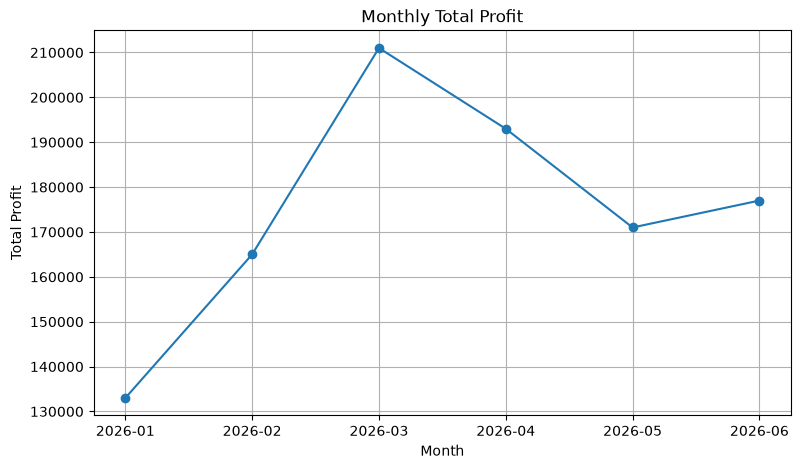

In [22]:
import matplotlib.pyplot as plt

monthly_plot = monthly_summary.copy()
monthly_plot.index = monthly_plot.index.astype(str)

monthly_plot["Total_Profit"].plot(
    kind="line",
    marker="o",
    figsize=(9, 5)
)

plt.title("Monthly Total Profit")
plt.xlabel("Month")
plt.ylabel("Total Profit")
plt.grid(True)
plt.show()

In [23]:
df.to_csv("financial_data_cleaned.csv", index=False)

print("Cleaned dataset exported successfully.")

Cleaned dataset exported successfully.


In [24]:
df.to_excel("financial_data_cleaned.xlsx", index=False)

print("Excel file exported successfully.")

Excel file exported successfully.


In [25]:
print("FINAL DATA QUALITY CHECK")
print("------------------------")
print("Rows:", len(df))
print("Columns:", len(df.columns))
print("Duplicate rows:", df.duplicated().sum())
print("Missing values:", df.isnull().sum().sum())

print("\nFinal columns:")
print(df.columns.tolist())

FINAL DATA QUALITY CHECK
------------------------
Rows: 25
Columns: 9
Duplicate rows: 0
Missing values: 0

Final columns:
['Date', 'Company', 'Sector', 'Revenue', 'Cost', 'Region', 'Profit', 'Profit_Margin_%', 'Month']


In [27]:
# Create a copy for the SQL database
df_sql = df.copy()

# Convert Pandas Period values into normal text for SQLite
df_sql["Month"] = df_sql["Month"].astype(str)

# Convert dates to a standard text format for SQLite
df_sql["Date"] = df_sql["Date"].dt.strftime("%Y-%m-%d")

# Load the cleaned data into SQLite
df_sql.to_sql(
    "financial_data",
    conn,
    if_exists="replace",
    index=False
)

print("SQL database created successfully.")

SQL database created successfully.


In [28]:
query = """
SELECT *
FROM financial_data;
"""

sql_result = pd.read_sql_query(query, conn)

sql_result.head()

,Date,Company,Sector,Revenue,Cost,Region,Profit,Profit_Margin_%,Month
0,2026-01-05,Apple,Technology,120000.0,80000.0,USA,40000.0,33.33,2026-01
1,2026-01-12,Microsoft,Technology,110000.0,72000.0,USA,38000.0,34.55,2026-01
2,2026-01-19,Tesla,Automotive,90000.0,70000.0,USA,20000.0,22.22,2026-01
3,2026-01-26,Barclays,Banking,85000.0,50000.0,UK,35000.0,41.18,2026-01
4,2026-02-02,Hsbc,Banking,95000.0,55000.0,UK,40000.0,42.11,2026-02


In [29]:
query = """
SELECT
    Company,
    Revenue,
    Cost,
    Profit,
    "Profit_Margin_%"
FROM financial_data
ORDER BY Profit DESC;
"""

result = pd.read_sql_query(query, conn)
result

,Company,Revenue,Cost,Profit,Profit_Margin_%
0,Microsoft,142000.0,86000.0,56000.0,39.44
1,Apple,150000.0,95000.0,55000.0,36.67
2,Microsoft,138000.0,84000.0,54000.0,39.13
3,Microsoft,135000.0,82000.0,53000.0,39.26
4,Apple,145000.0,92000.0,53000.0,36.55
5,Apple,140000.0,90000.0,50000.0,35.71
6,Hsbc,112000.0,64000.0,48000.0,42.86
7,Microsoft,125000.0,78000.0,47000.0,37.60
8,Hsbc,108000.0,62000.0,46000.0,42.59
9,Apple,130000.0,85000.0,45000.0,34.62


In [30]:
query = """
SELECT
    Company,
    SUM(Revenue) AS Total_Revenue,
    SUM(Cost) AS Total_Cost,
    SUM(Profit) AS Total_Profit
FROM financial_data
GROUP BY Company
ORDER BY Total_Profit DESC;
"""

company_summary = pd.read_sql_query(query, conn)
company_summary

,Company,Total_Revenue,Total_Cost,Total_Profit
0,Microsoft,650000.0,402000.0,248000.0
1,Apple,685000.0,442000.0,243000.0
2,Hsbc,517000.0,298000.0,219000.0
3,Barclays,471000.0,270000.0,201000.0
4,Tesla,499000.0,360000.0,139000.0


In [32]:
query = """
SELECT
    Sector,
    SUM(Revenue) AS Total_Revenue,
    SUM(Cost) AS Total_Cost,
    SUM(Profit) AS Total_Profit,
    ROUND(AVG("Profit_Margin_%"), 2) AS Avg_Profit_Margin
FROM financial_data
GROUP BY Sector
ORDER BY Total_Profit DESC;
"""

sector_summary = pd.read_sql_query(query, conn)
sector_summary

,Sector,Total_Revenue,Total_Cost,Total_Profit,Avg_Profit_Margin
0,Technology,1335000.0,844000.0,491000.0,36.69
1,Banking,988000.0,568000.0,420000.0,42.49
2,Automotive,499000.0,360000.0,139000.0,27.73


In [33]:
query = """
SELECT
    Date,
    Company,
    Sector,
    Revenue,
    Cost,
    Profit,
    "Profit_Margin_%"
FROM financial_data
WHERE Profit > 40000
ORDER BY Profit DESC;
"""

high_profit = pd.read_sql_query(query, conn)
high_profit

,Date,Company,Sector,Revenue,Cost,Profit,Profit_Margin_%
0,2026-06-01,Microsoft,Technology,142000.0,86000.0,56000.0,39.44
1,2026-05-25,Apple,Technology,150000.0,95000.0,55000.0,36.67
2,2026-04-27,Microsoft,Technology,138000.0,84000.0,54000.0,39.13
3,2026-03-23,Microsoft,Technology,135000.0,82000.0,53000.0,39.26
4,2026-04-20,Apple,Technology,145000.0,92000.0,53000.0,36.55
5,2026-03-16,Apple,Technology,140000.0,90000.0,50000.0,35.71
6,2026-06-22,Hsbc,Banking,112000.0,64000.0,48000.0,42.86
7,2026-02-16,Microsoft,Technology,125000.0,78000.0,47000.0,37.60
8,2026-05-18,Hsbc,Banking,108000.0,62000.0,46000.0,42.59
9,2026-02-09,Apple,Technology,130000.0,85000.0,45000.0,34.62


In [34]:
query = """
SELECT
    Company,
    SUM(Revenue) AS Total_Revenue,
    SUM(Profit) AS Total_Profit
FROM financial_data
GROUP BY Company
HAVING SUM(Profit) > 200000
ORDER BY Total_Profit DESC;
"""

profitable_companies = pd.read_sql_query(query, conn)
profitable_companies

,Company,Total_Revenue,Total_Profit
0,Microsoft,650000.0,248000.0
1,Apple,685000.0,243000.0
2,Hsbc,517000.0,219000.0
3,Barclays,471000.0,201000.0


In [35]:
query = """
SELECT
    Date,
    Company,
    Sector,
    Revenue,
    Profit,
    CASE
        WHEN Profit >= 50000 THEN 'High Profit'
        WHEN Profit >= 40000 THEN 'Medium Profit'
        ELSE 'Low Profit'
    END AS Profit_Category
FROM financial_data
ORDER BY Profit DESC;
"""

profit_categories = pd.read_sql_query(query, conn)
profit_categories

,Date,Company,Sector,Revenue,Profit,Profit_Category
0,2026-06-01,Microsoft,Technology,142000.0,56000.0,High Profit
1,2026-05-25,Apple,Technology,150000.0,55000.0,High Profit
2,2026-04-27,Microsoft,Technology,138000.0,54000.0,High Profit
3,2026-03-23,Microsoft,Technology,135000.0,53000.0,High Profit
4,2026-04-20,Apple,Technology,145000.0,53000.0,High Profit
5,2026-03-16,Apple,Technology,140000.0,50000.0,High Profit
6,2026-06-22,Hsbc,Banking,112000.0,48000.0,Medium Profit
7,2026-02-16,Microsoft,Technology,125000.0,47000.0,Medium Profit
8,2026-05-18,Hsbc,Banking,108000.0,46000.0,Medium Profit
9,2026-02-09,Apple,Technology,130000.0,45000.0,Medium Profit


In [36]:
query = """
SELECT
    Sector,
    COUNT(*) AS Number_of_Records,
    SUM(Revenue) AS Total_Revenue,
    SUM(Cost) AS Total_Cost,
    SUM(Profit) AS Total_Profit,
    ROUND(AVG("Profit_Margin_%"), 2) AS Avg_Profit_Margin
FROM financial_data
GROUP BY Sector
HAVING SUM(Profit) > 100000
ORDER BY Total_Profit DESC;
"""

final_sql_summary = pd.read_sql_query(query, conn)

final_sql_summary

,Sector,Number_of_Records,Total_Revenue,Total_Cost,Total_Profit,Avg_Profit_Margin
0,Technology,10,1335000.0,844000.0,491000.0,36.69
1,Banking,10,988000.0,568000.0,420000.0,42.49
2,Automotive,5,499000.0,360000.0,139000.0,27.73


### SQL Analysis Summary

SQL was used to analyse the cleaned financial dataset stored in SQLite. Queries were used to filter and sort records, calculate aggregate financial measures, group results by company and sector, and identify higher-performing records.

The final sector analysis showed that Technology generated the highest total profit at 491,000, followed by Banking at 420,000 and Automotive at 139,000. Banking had the highest average profit margin at 42.49%, compared with 36.69% for Technology and 27.73% for Automotive.

The SQL analysis demonstrated the use of SELECT, WHERE, ORDER BY, GROUP BY, HAVING, aggregate functions, aliases and CASE statements to turn the cleaned dataset into useful financial insights.